# P2 - RNNs

**Authors**:
- Pablo Diaz 
- Daniel Prieto

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Preprocessing of the data

Load the data and preprocess it

In [2]:
df = pd.read_csv("data/nyiso_hourly_load.csv")
df.head()

,Time Stamp,CAPITL,CENTRL,DUNWOD,GENESE,HUD VL,LONGIL,MHK VL,MILLWD,N.Y.C.,NORTH,WEST,total_load
0,2021-01-01 05:00:00+00:00,1229.765829,1652.064229,601.434650,980.770850,1001.962714,2061.066821,841.068829,319.410071,4808.552936,635.814164,1525.174400,15657.085493
1,2021-01-01 06:00:00+00:00,1199.764783,1606.512858,579.089583,934.267075,960.858267,1946.459783,807.607275,307.969050,4631.978808,633.340358,1473.827217,15081.675058
2,2021-01-01 07:00:00+00:00,1172.361075,1578.671450,559.861700,913.383017,936.291717,1855.849567,796.252242,301.264983,4486.644667,617.937925,1435.501408,14654.019750
3,2021-01-01 08:00:00+00:00,1164.461967,1556.862842,548.799792,901.166967,916.932750,1797.270625,794.205750,295.269642,4372.209042,615.713533,1417.398217,14380.291125
4,2021-01-01 09:00:00+00:00,1177.303475,1561.628092,545.171408,898.999517,915.355317,1791.221000,798.552250,295.507442,4336.574433,615.466042,1419.729483,14355.508458


In [3]:
print(df.columns)

Index(['Time Stamp', 'CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL',
       'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'WEST', 'total_load'],
      dtype='str')


Create a temporal split, since the data is time series data, we cannot do a random split. To respect the temporal order of the data, we will split it as follows:

- Training set: 2021–2023
- Validation set: 2024
- Test set: 2025

In [4]:
# split the data into training/validation/test sets

# Training Set 2021 to 2023
train_df = df[df["Time Stamp"] < "2024-01-01"]
print(len(train_df))

# Validation Set 2024
val_df = df[(df["Time Stamp"] >= "2024-01-01") & (df["Time Stamp"] < "2025-01-01")]
print(len(val_df))

# Test Set 2025
test_df = df[df["Time Stamp"] >= "2025-01-01"]
print(len(test_df))

# drop the "Time Stamp" column
train_df = train_df.drop(columns=["Time Stamp"])
val_df = val_df.drop(columns=["Time Stamp"])
test_df = test_df.drop(columns=["Time Stamp"])

26107
8784
8765


Now we start the preparation of the data that will be fed to the models. First we are going to standardize the data, using pandas utility functions on dataframes. We start by getting the mean and standard deviation of the training set and then we can apply the standardization to the training, validation and test sets. It is done this way to avoid data leakage, since we will be using just the training set to train the models, it it only fair to use just the training set to compute the mean and standard deviation.

In [5]:
mean = train_df.mean()
std = train_df.std()

print(f"Mean:\n{mean}\n")
print(f"Standard Deviation:\n{std}\n")

Mean:
CAPITL         1327.515791
CENTRL         1736.799880
DUNWOD          646.373512
GENESE         1087.183369
HUD VL         1051.645915
LONGIL         2276.543855
MHK VL          837.988563
MILLWD          322.531092
N.Y.C.         5593.559854
NORTH           646.981059
WEST           1676.361131
total_load    17203.484021
dtype: float64

Standard Deviation:
CAPITL         233.315696
CENTRL         272.144257
DUNWOD         146.049529
GENESE         189.547436
HUD VL         232.391308
LONGIL         634.965917
MHK VL         159.596627
MILLWD          76.722991
N.Y.C.        1148.912783
NORTH           65.901310
WEST           224.922815
total_load    3085.204590
dtype: float64



In [6]:
train_df_scaled = (train_df - mean) / std
val_df_scaled = (val_df - mean) / std
test_df_scaled = (test_df - mean) / std

At this point the data is standardized, but we still need to prepare the data in a way that can be fed to the recurrent models. We need to create sequences of data that will be fed to the models. For this point we tried different sequence lengths with the base RNN model, to find which sequence length worked best at first. We started with a sequence length of 168 (7 days) since we had hypothesized that the weekly patterns would be of interest. However, after some experimentation, we found that shorther sequences worked better, and we set a sequence length of 24 hours for all the experiments. This will ensure a fair comparison between the different models, since they will all be trained with the same sequence length.

In [7]:
from keras.utils import timeseries_dataset_from_array

# sequences of 168 hours (1 week) to predict total load 3 hours ahead
sequence_length = 24
# sequence_length = 72

batch_size = 32
sample_rate = 1  # hourly data, so one sample per hour
delay = sample_rate * (sequence_length + 3 - 1)  # 3 hours in the future

train_ds = timeseries_dataset_from_array(
    data=train_df_scaled.values,
    targets=train_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
)

val_ds = timeseries_dataset_from_array(
    data=val_df_scaled.values,
    targets=val_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

test_ds = timeseries_dataset_from_array(
    data=test_df_scaled.values,
    targets=test_df_scaled["total_load"][delay:].values,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

In [8]:
epochs = 100

### Utils functions

### Plot

In [9]:
import matplotlib.pyplot as plt


def plot_mae(history, std=1.0):
    loss = [v * std for v in history.history["mae"]]
    val_loss = [v * std for v in history.history["val_mae"]]
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, "b-o", label="Training MAE")
    plt.plot(epochs, val_loss, "r--o", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.ylabel("MAE (MW)")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

## Baselines

### Last Value Baseline

A last value baseline is a simple model that just predicts the last value of the sequence as the next value. This is a really simple model but it can be a good baseline to compare the models. 

In [10]:
mean_total = mean["total_load"]
std_total = std["total_load"]


def evaluate_baseline(dataset, get_pred_fn):
    total_abs_error = 0
    samples_counter = 0
    for samples, targets in dataset:
        preds = get_pred_fn(samples) * std_total + mean_total
        tgts = targets * std_total + mean_total
        total_abs_error += np.sum(np.abs(preds - tgts))
        samples_counter += samples.shape[0]
    return total_abs_error / samples_counter


# last observed total_load value (position -1 in window, feature -1 = total_load)
last_value_fn = lambda samples: samples[:, -1, -1]

print(f"Last Value — Validation MAE: {evaluate_baseline(val_ds, last_value_fn):.2f}")
print(f"Last Value — Test MAE:       {evaluate_baseline(test_ds, last_value_fn):.2f}")

Last Value — Validation MAE: 1402.25
Last Value — Test MAE:       1399.68


The last value baseline is a very weak predictor model, since we are forecasting 3 hours ahead and electricity load is highly volatile across the day, repeating the value from 3 hours ago is not the optimal. However, it is a good baseline to compare the models, since if the models cannot beat this baseline, then they are not learning anything useful from the data.

### Last Day Baseline

A last day baseline is a simple model that just predicts the value of the same hour of the previous day as the next value. This is a really simple model as well, but it could be useful to compare the models since the data might have strong daily patterns.

In [35]:
# Target is 3h after the last element (pos 24), so 24h before target is pos 24+3-24 = 3
daily_fn = lambda samples: samples[:, 2, -1]

print(f"Daily Baseline — Validation MAE: {evaluate_baseline(val_ds, daily_fn):.2f}")
print(f"Daily Baseline — Test MAE:       {evaluate_baseline(test_ds, daily_fn):.2f}")

Daily Baseline — Validation MAE: 886.04
Daily Baseline — Test MAE:       1005.23


This is a stronger baseline than the last value baseline, because it takes into account the daily patterns of consumption. However not a very strong baseline yet. 

### Neural Baseline (Conv1D + Dense)

For this model we will use a two layers Conv1D model followed by a Dense layer. The most important parameter of the layers is the padding, which is `causal`, which means that the model will only use the past values to make predictions and not future values. This was taken from the [Keras documentation](https://keras.io/api/layers/convolution_layers/convolution1d/) as it states that it is useful for the time series data. The rest of the parameters were just random choices, since the main goal of this model is to be a baseline.

In [12]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.Conv1D(64, 5, activation="relu", padding="causal")(inputs)
x = layers.Conv1D(32, 3, activation="relu", padding="causal")(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)
model_conv = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_conv.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.2, min_lr=1e-5),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
model_conv.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

history_conv = model_conv.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0568 - mae: 0.1736 - val_loss: 0.0340 - val_mae: 0.1420 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0274 - mae: 0.1261 - val_loss: 0.0353 - val_mae: 0.1400 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0221 - mae: 0.1128 - val_loss: 0.0389 - val_mae: 0.1533 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0191 - mae: 0.1054 - val_loss: 0.0246 - val_mae: 0.1208 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0180 - mae: 0.1017 - val_loss: 0.0279 - val_mae: 0.1260 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0171 - mae: 0.0986 - val_loss: 0.0250 - val_mae: 0.1227 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0153 - mae: 0.0937 - val_loss: 0.0275 - val_mae: 0.1210 - learning_rate: 0.0010

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0257 - mae: 0.1165
Test MAE: 359.52
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0165 - mae: 0.0946
Val MAE:  291.78


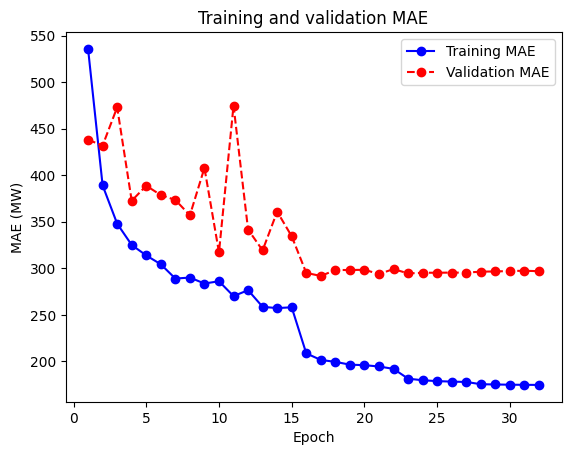

In [13]:
model_conv = keras.models.load_model("models_s24_b32/jena_conv.keras")
print(f"Test MAE: {model_conv.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Val MAE:  {model_conv.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_conv, std=std_total)

This models achieves impressive results, taking into account the simplicity of its architecture. It already beats the previous baselines by a 3x improvement in the MAE metric. We did not expect this model to perform so well since it is really simple in hindsight. It is a really strong baseline to compare, adn it will be hard to beat with the recurrent models. The main reason might be the causal padding mentioned above.

In the graph and the training output we can observe a clear overiftting of the model. The training loss is much lower than the validation loss, almost 10x throughout the whole training. The difference in the MAE metric is also quite large which supports this hypothesis.

Despite the overfitting, this model is a strong baseline obtaining a MAE of 359.52 in the test set.

## Part 2: Recurrent Models

For each architecture type we will follow a consistent approach to ensure fair conmparisons:
- **Base model** — a simple architecture with a single recurrent layer and no regularization.
- **Recurrent dropout** — applying a fixed dropout mask to recurrent activations (Gal & Ghahramani, 2016).
- **Stacked layers** — increasing model depth using `return_sequences=True` on the first layer.

We explore different configurations for all the models, but we will report the best configuration found for each one.

For the SimpleRNN we do not explore the stacked option since it is not a very powerful model and it is not expected to benefit from having more layers. Mainly due to the vanishing gradient problem that SimpleRNNs have, which makes it difficult for the model to learn long-term dependencies.

The RNNs will use the `AdamW` optimizer while the LSTMs and GRUs will use the RMSprop optimizer. This is because in the first experiments we found the AdamW worked better for the RNNs while the RMSprop worked better for the other two.

We will also use the same batch size of 32, stated when the sequences were created. We tried 64 and 128 as well, but we found that 32 worked almost always better. The epochs will be set to 100, but we will use early stopping to stop the training when the model starts overfitting.

The callbacks used for all the models are the same as well:

- `EarlyStopping` with a patience of 15 since we are also using a reduction of learning rate and the model might need some time to recover from the learning rate reduction.
- `ReduceLROnPlateau` with a patience of 5 and a factor of 0.2, to reduce the learning rate when the model starts overfitting.
- `ModelCheckpoint` to save the best model during training, so we can load it later to evaluate it on the test set.

### SimpleRNN

#### Base model

As mentioned before, a lot of configurations were explored for the SimpleRNN, mainly to see what configuration of the preprocessing step (sequence length) worked best, as well as architectural changes (regularization, recurrent dropout). We started testing the models with a sequence length of 168 (7 days) since we had hypothesized that the weekly patterns would be of interest. However, after some experimentation, we found that a sequence of 24 hours worked better. This might be because of the vanishing gradient problem that SimpleRNNs have, which makes it difficult for the model to learn long-term dependencies.

For the archictecture, we use 128 units, in earlier experiments we found that the model benefited from having more units. A Dense(32) hidden layer is added between the recurrent output and the final output layer, which showed to be effective but just in this architecture type.

In [14]:
from typing import cast

import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(128)(inputs)
x = layers.Dense(32, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_rnn_128.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-5),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

history_simple_rnn = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0556 - mae: 0.1655 - val_loss: 0.0360 - val_mae: 0.1488 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0250 - mae: 0.1213 - val_loss: 0.0314 - val_mae: 0.1335 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0222 - mae: 0.1140 - val_loss: 0.0398 - val_mae: 0.1600 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0200 - mae: 0.1077 - val_loss: 0.0235 - val_mae: 0.1188 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0181 - mae: 0.1026 - val_loss: 0.0253 - val_mae: 0.1207 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0175 - mae: 0.1006 - val_loss: 0.0215 - val_mae: 0.1103 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0173 - mae: 0.0998 - val_loss: 0.0236 - val_mae: 0.1194 - learning_rate: 0.0010

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0288 - mae: 0.1218
Test MAE: 375.67
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0160 - mae: 0.0922
Val MAE:  284.44


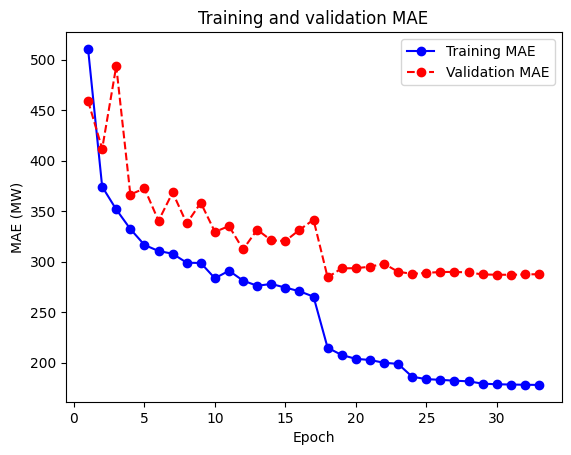

In [15]:
model = keras.models.load_model("models_s24_b32/jena_rnn_128.keras")
model = cast(keras.Model, model)

print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Val MAE:  {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_simple_rnn, std=std_total)

Overall, the model performs decently, achieving a MAE of 375.67 on the test set, way better than the heuristic baselines but not as good as the Conv1D baseline on the test set. 

Similarly to the Conv1D baseline, we can observe a clear overfitting in the training (see graph above). The training loss is much lower than the validation loss again. In the validation set the model performs better than the Conv1D baseline but in the test set it performs worse, which might indicate the model is overfitting as well, or that it is not able to capture the sequential patterns of the data as well as the Conv1D model.

#### SimpleRNN with recurrent dropout

Since the previous model showed some overfitting, the regularization applied in this model might be of help to reduce it and improve the generalization of the model. We are going to apply only a small amount of:

- Recurrent dropout of 0.1 to the recurrent layer
- Dropout of 0.2 after the Dense layer

To compensate for the regularization, we also increase the number of units to 256. 

In [16]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.SimpleRNN(256, recurrent_dropout=0.1)(inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_rnn_dropout.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-5, verbose=1),
]

optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_rnn_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0976 - mae: 0.2371 - val_loss: 0.0448 - val_mae: 0.1625 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0574 - mae: 0.1852 - val_loss: 0.0336 - val_mae: 0.1430 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0470 - mae: 0.1675 - val_loss: 0.0373 - val_mae: 0.1542 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0455 - mae: 0.1640 - val_loss: 0.0349 - val_mae: 0.1452 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0434 - mae: 0.1600 - val_loss: 0.0319 - val_mae: 0.1388 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0430 - mae: 0.1598 - val_loss: 0.0452 - val_mae: 0.1594 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0456 - mae: 0.1632 - val_loss: 0.0368 - val_mae: 0.1488 - learning_rate: 0.0010

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0356 - mae: 0.1355
Test MAE: 417.92
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0190 - mae: 0.1005
Val MAE:  310.08


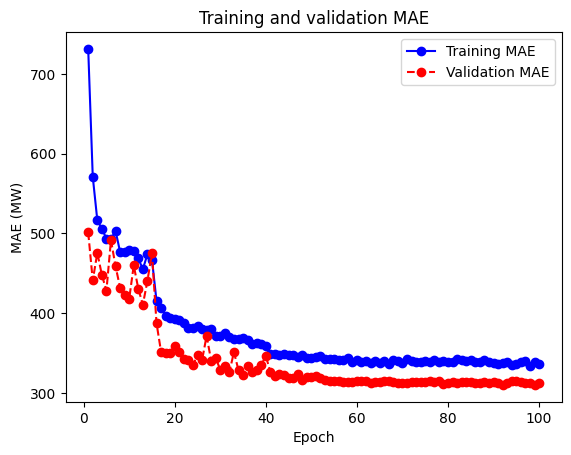

In [17]:
model = keras.models.load_model("models_s24_b32/jena_rnn_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Val MAE:  {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_rnn_dropout, std=std_total)

Applying the recurrent droput and the droput layer seems to not be helping the model improve, but rather it makes it worse. It performs worse in all the sets. This might be because the model is not overfitting that much, and the regularization is just making it worse. The model is already not performing that well, so adding regularization just makes it worse.

An interesting observation of the graph and the training history is that the validation loss is consistently lower than the training loss, which we did not expect. The same applies to the MAE metric, this could be because the recurrent droput is not active during inference, only in training, which makes the loss and MAE inflated during training.

The most impressive result is the difference in the MAE metric between the validation and the test set, there is a different of about 100 points, which is even larger than the previous model.

Despite incresing the size of the model, to account for regularization, the model is worse than the base model and it seems the increase and the regularization are not helping the model. 

### LSTM

#### Base model

The base LSTM uses a single LSTM layer with 128 units (same as the SimpleRNN) with the added L2 regularization to the kernel and recurrent weights, with a factor of 0.0001. This is really small and not noticeable as recurrent or dropout, but it is still a form of regularization that can help the model to generalize better. The rest of the architecture is the same, only this time we do not add the Dense layer since it did not show to be good in initial experiments with the LSTM architecture, maybe because the LSTM is already a large model and it does not benefit from the added capacity of the Dense layer for this problem. 

In [18]:
import keras
from keras import layers
from keras import regularizers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(128, kernel_regularizer=regularizers.l2(1e-4))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_lstm.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

custom_optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=custom_optimizer, loss="mse", metrics=["mae"])
history_lstm = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)
# model = keras.models.load_model("models_s24_b32/jena_lstm.keras")
# print(f"Test MAE: {model.evaluate(test_ds_72)[1] * std_total:.2f}")
# print(f'Validation MAE: {model.evaluate(val_ds_72)[1] * std_total:.2f}')

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0648 - mae: 0.1855 - val_loss: 0.0931 - val_mae: 0.2366 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0283 - mae: 0.1238 - val_loss: 0.0368 - val_mae: 0.1417 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0232 - mae: 0.1107 - val_loss: 0.0394 - val_mae: 0.1456 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0206 - mae: 0.1041 - val_loss: 0.0285 - val_mae: 0.1220 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0189 - mae: 0.0992 - val_loss: 0.0382 - val_mae: 0.1444 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0178 - mae: 0.0962 - val_loss: 0.0274 - val_mae: 0.1218 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0168 - mae: 0.0933 - val_loss: 0.0298 - val_mae: 0.1268 - learning_rate: 0.0010

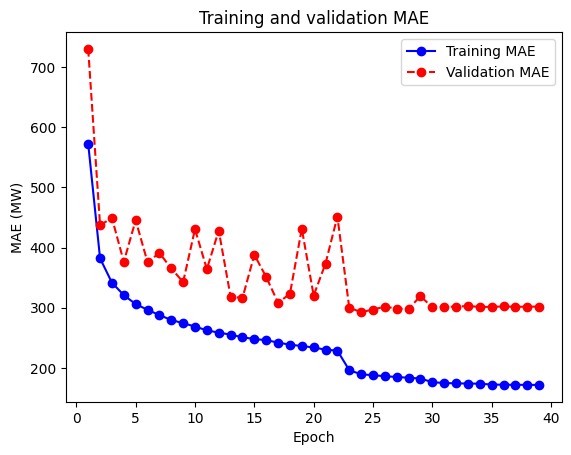

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0325 - mae: 0.1292
Test MAE: 398.57
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0185 - mae: 0.0949
Validation MAE: 292.70


In [19]:
plot_mae(history_lstm, std=std_total)
model = keras.models.load_model("models_s24_b32/jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

The results are not impressive, it is not able to beat the Conv1D baseline or the SimpleRNN model. The L2 added does not seem to be doing anything, we can still see overfitting in the training curves. 

#### LSTM with recurrent dropout

Following the same pattern are previously, we apply the same regularization strategy as with SimpleRNN: `reccurent_droput=0.1` on the LSTM and `Dropout(0.1)` on its output. This will compare the effect of the kernel regularization with the L2 and the regularization with dropout and recurrent dropout.

In [ ]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(128, recurrent_dropout=0.1)(inputs)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_lstm_dropout.keras",
        save_best_only=True,
        monitor="val_loss",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]
epochs = 100
optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_lstm_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1564 - mae: 0.2901
Epoch 1: val_loss improved from None to 0.10717, saving model to jena_lstm_dropout.keras

Epoch 1: finished saving model to jena_lstm_dropout.keras
816/816 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0855 - mae: 0.2198 - val_loss: 0.1072 - val_mae: 0.2648 - learning_rate: 0.0010
Epoch 2/100
814/816 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0434 - mae: 0.1629
Epoch 2: val_loss improved from 0.10717 to 0.03198, saving model to jena_lstm_dropout.keras

Epoch 2: finished saving model to jena_lstm_dropout.keras
816/816 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0407 - mae: 0.1574 - val_loss: 0.0320 - val_mae: 0.1371 - learning_rate: 0.0010
Epoch 3/100
813/816 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0337 - mae: 0.1425
Epoch 3: val_loss did not improve from 0.03198
816/816 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0330 - mae: 0.1408 - val_loss: 0.0428 - val_mae: 0.1575 - learning_rate: 0.0010
Epoch 

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0301 - mae: 0.1269
Test MAE: 391.36
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0171 - mae: 0.0959
Validation MAE: 295.81


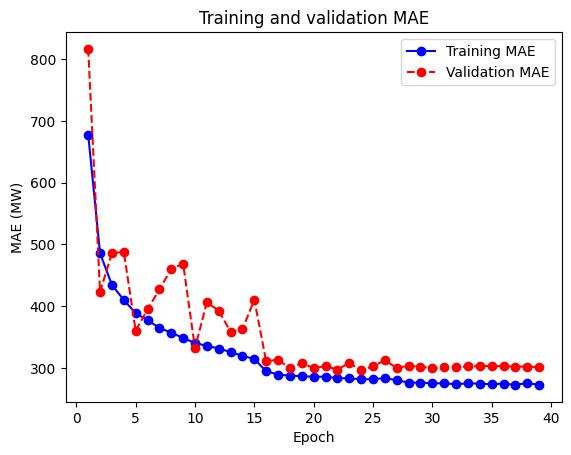

In [22]:
model = keras.models.load_model("models_s24_b32/jena_lstm_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_lstm_dropout, std=std_total)

It achieves better results then the base LSTM, 391 MAE on the test set. The recurrent regularization seems to be helping more the model than the L2 regularization. We can see that there is not much overfitting in the training curves compared to the previous model. Maybe if we increased the number unitls we could achieve better results, but it would require a lot of tweaking different hyperparameters to find the optimal configuration, and LSTMs are already quite expensive to train, so we did not explore that option.

#### Stacked LSTM

To increase model capacity we stack two LSTM layers. The first must use `return_sequences=True` to pass the full output sequence to the second. Both layers will have a recurrent dropout of 0.1 to compensate for the additional capacity.

The untits were halved to 64 to compensate for the increase in the number of layers. 

In [23]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.LSTM(64, recurrent_dropout=0.1, return_sequences=True)(inputs)
x = layers.LSTM(64, recurrent_dropout=0.1)(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_lstm_stacked.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_lstm_stacked = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.1151 - mae: 0.2575 - val_loss: 0.0868 - val_mae: 0.2255 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0524 - mae: 0.1776 - val_loss: 0.0515 - val_mae: 0.1732 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0386 - mae: 0.1519 - val_loss: 0.0395 - val_mae: 0.1516 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0325 - mae: 0.1388 - val_loss: 0.0278 - val_mae: 0.1273 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0294 - mae: 0.1318 - val_loss: 0.0303 - val_mae: 0.1330 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0268 - mae: 0.1260 - val_loss: 0.0282 - val_mae: 0.1287 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0249 - mae: 0.1209 - val_loss: 0.0242 - val_mae: 0.1218 - learnin

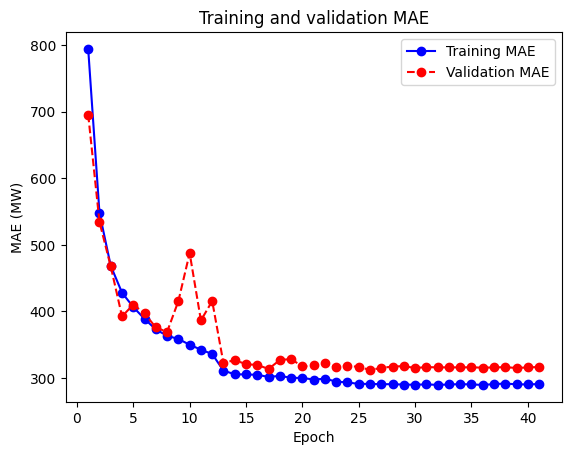

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0352 - mae: 0.1427
Test MAE: 440.29
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0188 - mae: 0.1011
Validation MAE: 312.01


In [24]:
plot_mae(history_lstm_stacked, std=std_total)

model = keras.models.load_model("models_s24_b32/jena_lstm_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

This is the weakest of the models so far, it performs worse than the base LSTM and the LSTM with recurrent dropout. Stacking two layers it does increase capability of the model but it also makes it more complex to train. Maybe the 24 hour window is not enough for the model to learn useful patterns with the addition of the second layer. The training is even more expensive than the previous LSTM models, and with this results already not that good, we did not explore other configurations of this model since it does not seem to be a good option for this problem.

### GRU

#### Base model

Same procedure as before, we have a single GRU layer with 128 units and L2 regularization, identical to the base LSTM model but with GRU units.

In [25]:
import keras
from keras import layers
from keras import regularizers

inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(128, kernel_regularizer=regularizers.l2(1e-4))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_gru.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001
    ),
]

custom_optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=custom_optimizer, loss="mse", metrics=["mae"])
history_gru = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0696 - mae: 0.1912 - val_loss: 0.0647 - val_mae: 0.1903 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0290 - mae: 0.1260 - val_loss: 0.0828 - val_mae: 0.2131 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0239 - mae: 0.1137 - val_loss: 0.0412 - val_mae: 0.1539 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0217 - mae: 0.1084 - val_loss: 0.0244 - val_mae: 0.1148 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0200 - mae: 0.1033 - val_loss: 0.0407 - val_mae: 0.1596 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0189 - mae: 0.1004 - val_loss: 0.0554 - val_mae: 0.1702 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0180 - mae: 0.0977 - val_loss: 0.0488 - val_mae: 0.1636 - learning_rate: 0.0010

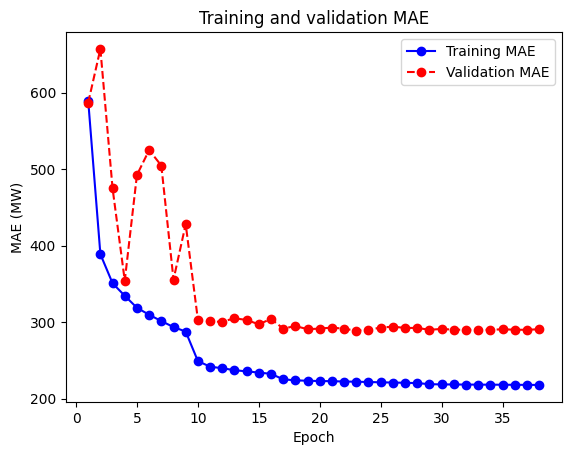

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0281 - mae: 0.1179
Test MAE: 363.90
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0174 - mae: 0.0936
Validation MAE: 288.85


In [26]:
plot_mae(history_gru, std=std_total)

model = keras.models.load_model("models_s24_b32/jena_gru.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

So far the best model in terms of test results of recurrent models, a MAE of 363.90 on the test. This might indicate that GRUs architecture is better suited for this problem than the LSTM, being able to capture longer terms dependencies more effectively than the LSTM and the SimpleRNN. It is also more efficient to train than the LSTM models so, overall, it seems to be the best option for this problem for now.

The graph again shows some overfitting, but not as much as the previous base models. 

#### GRU with recurrent dropout

Following the same pattern as before, we apply the same regularization strategy as with SimpleRNN: `recurrent_dropout=0.1` on the GRU and `Dropout(0.1)` on its output, to compare the effect of the kernel regularization with the L2 and the regularization with dropout and recurrent dropout.

In [27]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(128, recurrent_dropout=0.1)(inputs)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_gru_dropout.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)

model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_gru_dropout = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0879 - mae: 0.2224 - val_loss: 0.0622 - val_mae: 0.1964 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0408 - mae: 0.1573 - val_loss: 0.0723 - val_mae: 0.2071 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0340 - mae: 0.1424 - val_loss: 0.0455 - val_mae: 0.1631 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0298 - mae: 0.1336 - val_loss: 0.0446 - val_mae: 0.1572 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0281 - mae: 0.1292 - val_loss: 0.0291 - val_mae: 0.1309 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0267 - mae: 0.1258 - val_loss: 0.0374 - val_mae: 0.1435 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0251 - mae: 0.1224 - val_loss: 0.0249 - val_mae: 0.1185 - learnin

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0296 - mae: 0.1254
Test MAE: 386.86
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0173 - mae: 0.0968
Validation MAE: 298.76


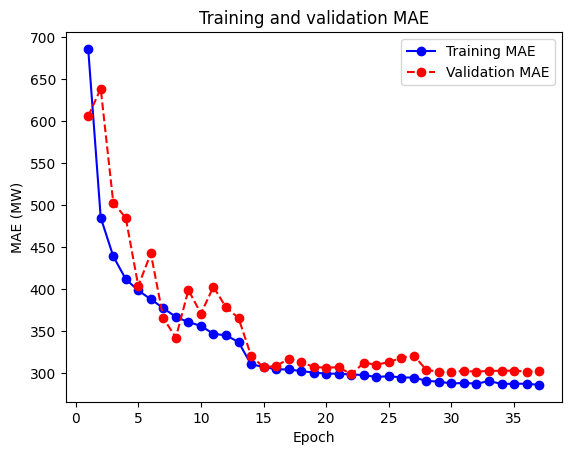

In [28]:
model = keras.models.load_model("models_s24_b32/jena_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")

plot_mae(history_gru_dropout, std=std_total)

Addin the recurrent dropout and the dropout layer does not seem to be helping the model. Similarly to the other architectures increasin the test MAE from 364 to 387 MW. The base GRU already generalizes well enough so adding droput might mean feeding the model unnccessary noise during training, which makes it worse. The training curves have improved from the base model, but since the results are worse, it seems that the regularization is not helping the model to generalize better, and it is just making it worse.

#### Stacked GRU

Two GRU layers of 64 units each with `return_sequences=True` on the first layer and 
`recurrent_dropout=0.1` on both, matching the stacked LSTM configuration.

In [29]:
inputs = keras.Input(shape=(sequence_length, train_df_scaled.shape[-1]))
x = layers.GRU(64, recurrent_dropout=0.1, return_sequences=True)(inputs)
x = layers.GRU(64, recurrent_dropout=0.1)(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "models_s24_b32/jena_gru_stacked.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=5, min_lr=0.00001, verbose=1
    ),
]

optimizer = keras.optimizers.RMSprop(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
history_gru_stacked = model.fit(
    train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks
)

Epoch 1/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0904 - mae: 0.2267 - val_loss: 0.0675 - val_mae: 0.2078 - learning_rate: 0.0010
Epoch 2/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0444 - mae: 0.1646 - val_loss: 0.0752 - val_mae: 0.2120 - learning_rate: 0.0010
Epoch 3/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0359 - mae: 0.1472 - val_loss: 0.0582 - val_mae: 0.1846 - learning_rate: 0.0010
Epoch 4/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0319 - mae: 0.1373 - val_loss: 0.0272 - val_mae: 0.1264 - learning_rate: 0.0010
Epoch 5/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0291 - mae: 0.1318 - val_loss: 0.0324 - val_mae: 0.1429 - learning_rate: 0.0010
Epoch 6/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0276 - mae: 0.1279 - val_loss: 0.0377 - val_mae: 0.1458 - learning_rate: 0.0010
Epoch 7/100
816/816 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0257 - mae: 0.1238 - val_loss: 0.0242 - val_mae: 0.1194 - learnin

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0330 - mae: 0.1336
Test MAE: 412.07
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0179 - mae: 0.0992
Validation MAE: 306.08


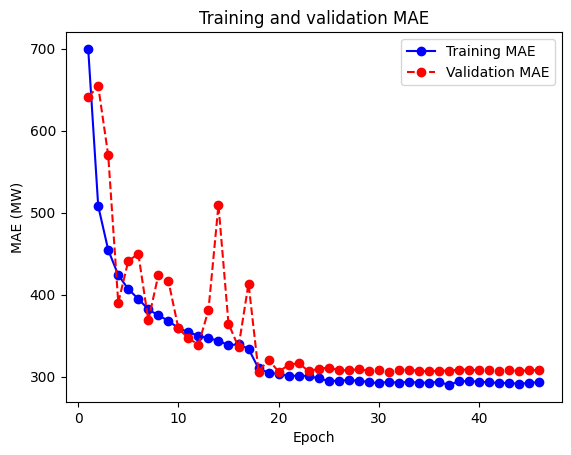

In [30]:
model = keras.models.load_model("models_s24_b32/jena_gru_stacked.keras")
print(f"Test MAE: {model.evaluate(test_ds)[1] * std_total:.2f}")
print(f"Validation MAE: {model.evaluate(val_ds)[1] * std_total:.2f}")


plot_mae(history_gru_stacked, std=std_total)

Same as we saw previously with the stacked LSTM, this is the worse GRU model. More layers does not help with short sequences like the ones we are using, and it also makes training more difficult.

In the end, the best model is the base GRU, which is the one that achieves the best results on the test set. The recurrent dropout and the stacked layers do not seem to be helping the model to generalize better, and they just make it worse. The base GRU already has enough capacity to learn the patterns of the data, and adding more layers or regularization just makes it worse.

## Analysis and Comparison

We collect all test MAEs (denormalized, in MW) and display them in a single table and bar chart.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

print("Model comparison:")


def get_maes(model_path):
    m = keras.models.load_model(model_path)
    return (
        m.evaluate(test_ds, verbose=0)[1] * std_total,
        m.evaluate(val_ds, verbose=0)[1] * std_total,
    )


model_names = [
    "Last Value Baseline",
    "Daily Baseline",
    "Conv1D Neural Baseline",
    "SimpleRNN (128 units)",
    "SimpleRNN + Dropout (256 units)",
    "LSTM (128 units)",
    "LSTM + Dropout (128 units)",
    "LSTM Stacked (64×2)",
    "GRU (128 units)",
    "GRU + Dropout (128 units)",
    "GRU Stacked (64×2)",
]

maes = [
    (
        evaluate_baseline(test_ds, last_value_fn),
        evaluate_baseline(val_ds, last_value_fn),
    ),
    (evaluate_baseline(test_ds, daily_fn), evaluate_baseline(val_ds, daily_fn)),
    get_maes("models_s24_b32/jena_conv.keras"),
    get_maes("models_s24_b32/jena_rnn_128.keras"),
    get_maes("models_s24_b32/jena_rnn_dropout.keras"),
    get_maes("models_s24_b32/jena_lstm.keras"),
    get_maes("models_s24_b32/jena_lstm_dropout.keras"),
    get_maes("models_s24_b32/jena_lstm_stacked.keras"),
    get_maes("models_s24_b32/jena_gru.keras"),
    get_maes("models_s24_b32/jena_gru_dropout.keras"),
    get_maes("models_s24_b32/jena_gru_stacked.keras"),
]

results_df = pd.DataFrame(
    {
        "Model": model_names,
        "Test MAE (MW)": [mae[0] for mae in maes],
        "Validation MAE (MW)": [mae[1] for mae in maes],
    }
)

results_df["Test MAE (MW)"] = results_df["Test MAE (MW)"].round(2)
results_df["Validation MAE (MW)"] = results_df["Validation MAE (MW)"].round(2)
print(results_df.to_string(index=False))

Model comparison:
                          Model  Test MAE (MW)  Validation MAE (MW)
            Last Value Baseline        1399.68              1402.25
                 Daily Baseline        1005.23               886.04
         Conv1D Neural Baseline         359.52               291.78
          SimpleRNN (128 units)         375.67               284.44
SimpleRNN + Dropout (256 units)         417.92               310.08
               LSTM (128 units)         398.57               292.70
     LSTM + Dropout (128 units)         391.36               295.81
            LSTM Stacked (64×2)         440.29               312.01
                GRU (128 units)         363.90               288.85
      GRU + Dropout (128 units)         386.86               298.76
             GRU Stacked (64×2)         412.07               306.08


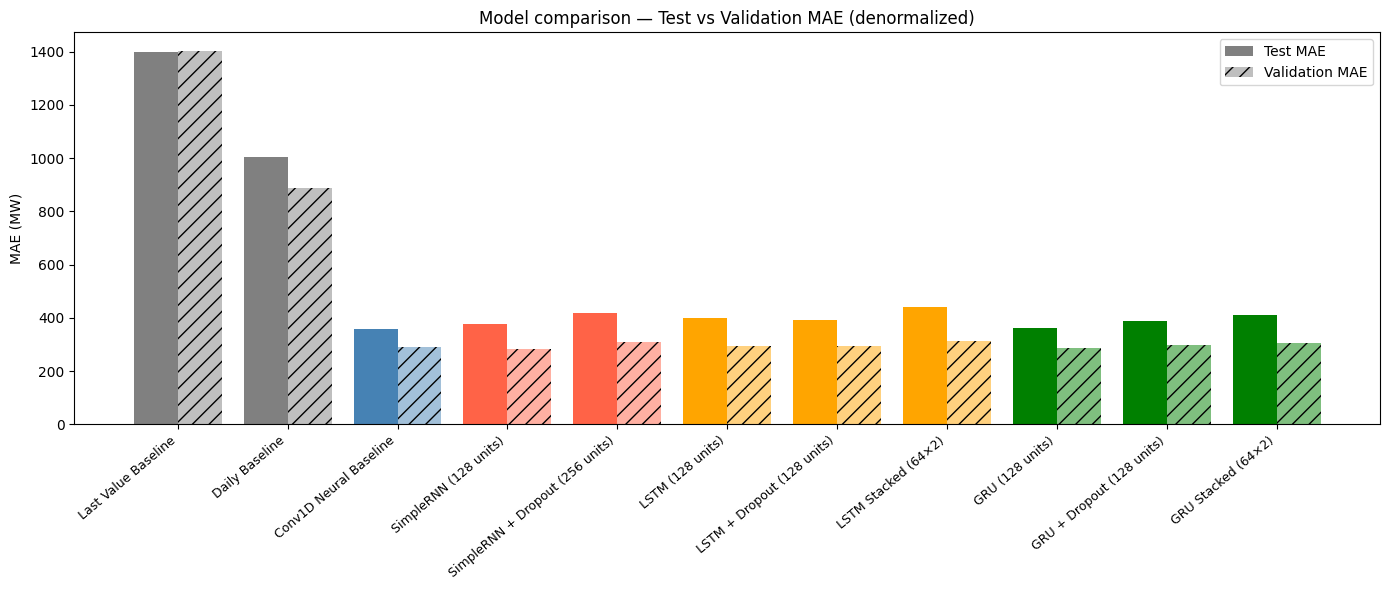

In [37]:
# Bar chart
colors = [
    "gray",
    "gray",
    "steelblue",
    "tomato",
    "tomato",
    "orange",
    "orange",
    "orange",
    "green",
    "green",
    "green",
]
x = np.arange(len(model_names))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))

bars_test = ax.bar(
    x - width / 2,
    [mae[0] for mae in maes],
    width,
    label="Test MAE",
    color=colors,
    alpha=1.0,
)
bars_val = ax.bar(
    x + width / 2,
    [mae[1] for mae in maes],
    width,
    label="Validation MAE",
    color=colors,
    alpha=0.5,
    hatch="//",
)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("MAE (MW)")
ax.set_title("Model comparison — Test vs Validation MAE (denormalized)")
ax.legend()
plt.tight_layout()
plt.show()

### Discussion

After testing all the different models, we can confidently say that all the neural are better than just a heuristic baseline, which is a good sign that the models are learning something useful for the data and the temporal relationships that exist with electricity load.

The Conv1D baseline is as good as the best recurrent models. This is a bit surprising since we expected the recurrent models to be better at capturing the temporal relationships of the data, but it could make sense that with that short of a sequence, the causal padding of the Conv1D is good enough.

In terms of recurrent models, the base SimpleRNN and base GRU are the best models, outperforming the LSTM models. This is likely due to the short 24 hour sequence length, which does not require the LSTM capibility of capturing long term dependencies. The smaller parameter than SimpleRNN and GRU have in comparison to LSTM architectures seem to be more than enough for this problem, and the added complexity of the LSTM does not seem to be helping the model to generalize better, it makes it overfit the training data. 

The regularization techniques applied did not help at all. We can see that the models with recurrent droput do not benefit from it:

- SimpleRNN without: 375.67 MW vs with 417.92
- GRU without: 363.90 MW vs with 386.86

Even with low regularization that was applied, the models did not benefit from it, which might indicate that the model were not that overfitted to the data in the first place, and that the regularization was just adding noise to the training process. 

Stacking did not help either, it never improved the results of the models. This might be because the sequence length is too short for the model to benefit from the added capacity of the second layer, and it also makes training more difficult, since it is a more complex model.

In the end, the best model is the base GRU, which is the one that achieves the best results on the test set. The recurrent dropout and the stacked layers do not seem to be helping the model to generalize better, and they just make it worse. The base GRU already has enough capacity to learn the patterns of the data, and adding more layers or regularization just makes it worse.